In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
# this is for jupyter notebook to show the plot in the notebook itself instead of opening a new window
%matplotlib inline

In [9]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [10]:
import pandas as pd

df = pd.read_csv("amazon.csv")  # or your exact file name
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [11]:
df.columns
for col in df.columns:
    print(col)

product_id
product_name
category
discounted_price
actual_price
discount_percentage
rating
rating_count
about_product
user_id
user_name
review_id
review_title
review_content
img_link
product_link


In [13]:
# Use CATEGORY column
data = df['category'].dropna()

# Get frequencies
observed_counts = data.value_counts()

# 🔥 IMPORTANT: take top 5 categories only (avoids too many categories issue)
observed_counts = observed_counts.head(5)

categories = observed_counts.index
observed = observed_counts.values

# Expected frequencies (equal distribution)
expected = np.array([sum(observed)/len(observed)] * len(observed))

# Chi-square test
chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Categories:", categories.tolist())
print("Observed:", observed)
print("Expected:", expected)
print("\nChi-square:", chi_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")



Categories: ['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables', 'Electronics|WearableTechnology|SmartWatches', 'Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones', 'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions', 'Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear']
Observed: [233  76  68  63  52]
Expected: [98.4 98.4 98.4 98.4 98.4]

Chi-square: 233.22357723577235
P-value: 2.6705119954168724e-49
Reject Null Hypothesis


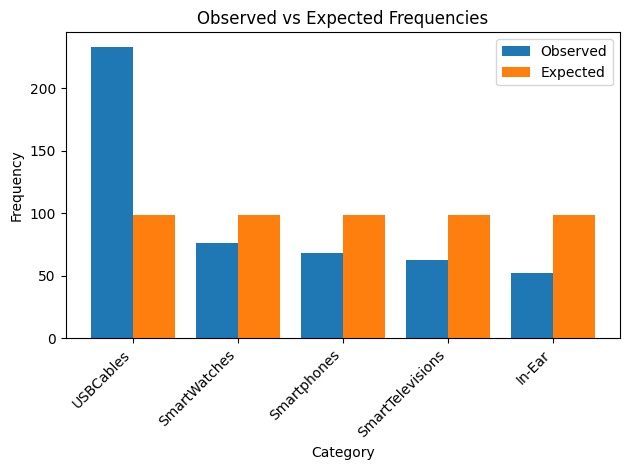

In [15]:
# ----------------------------
# GRAPH 1: Observed vs Expected
# ----------------------------
x = np.arange(len(categories))

# Shorten category names for better readability
shortened_categories = [cat.split('|')[-1] for cat in categories]

plt.figure()
plt.bar(x - 0.2, observed, width=0.4, label='Observed')
plt.bar(x + 0.2, expected, width=0.4, label='Expected')

plt.xticks(x, shortened_categories, rotation=45, ha='right') # Use shortened categories and adjust rotation/alignment
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title("Observed vs Expected Frequencies")
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

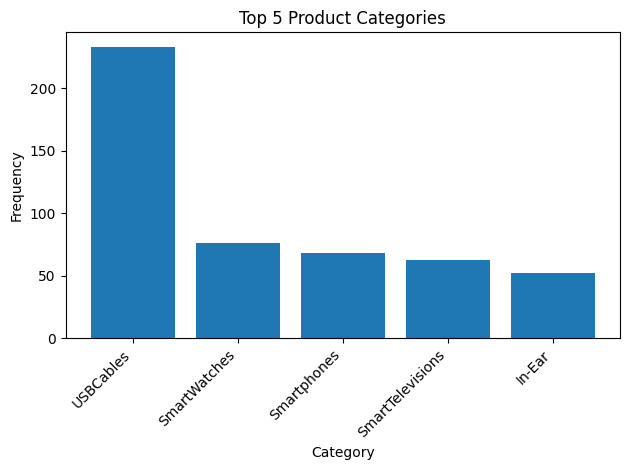

In [17]:
# ----------------------------
# GRAPH 2: Frequency Chart
# ----------------------------
plt.figure()
plt.bar(shortened_categories, observed)

plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title("Top 5 Product Categories")
plt.xticks(rotation=45, ha='right') # Use shortened categories and adjust rotation/alignment
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

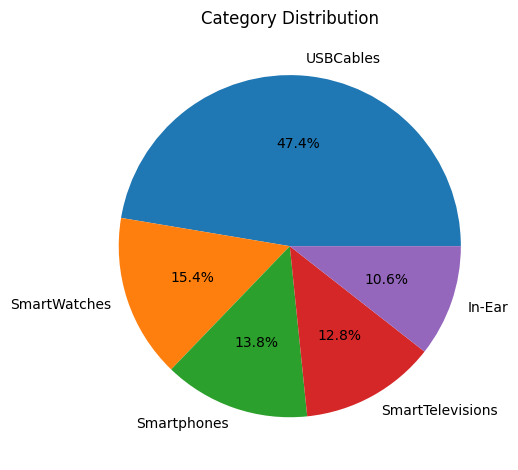

In [20]:
# ----------------------------
# GRAPH 3: Pie Chart
# ----------------------------
plt.figure()
plt.pie(observed, labels=shortened_categories, autopct='%1.1f%%')

plt.title("Category Distribution")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()